In [1]:
pip install wfdb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
############################################################
# IMPORT LIBRARIES
############################################################

import os
import ast

import numpy as np
import pandas as pd

from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.signal import butter, filtfilt

In [3]:
############################################################
# DATASET PATH
############################################################

DATA_PATH = "/kaggle/input/datasets/ranajoynag/ecg-corpus/ptb_xl_data/"

In [4]:
############################################################
# LOAD METADATA
############################################################

df = pd.read_csv(DATA_PATH + "ptbxl_database.csv")

# Convert SCP code column from string → dictionary
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

print("Total ECG samples:", len(df))

df.head()

Total ECG samples: 21799


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [5]:
############################################################
# LOAD DIAGNOSTIC STATEMENTS
############################################################

scp_df = pd.read_csv(DATA_PATH + "scp_statements.csv", index_col=0)

# Keep only diagnostic statements
scp_df = scp_df[scp_df.diagnostic == 1]

scp_df.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [6]:
############################################################
# MAP SCP CODES TO DIAGNOSTIC CLASSES
############################################################

def aggregate_diagnostic(y_dict):

    diag = []

    for key in y_dict.keys():

        if key in scp_df.index:
            diag.append(scp_df.loc[key].diagnostic_class)

    return list(set(diag))


df["diagnostic_superclass"] = df["scp_codes"].apply(aggregate_diagnostic)

df[["ecg_id", "diagnostic_superclass"]].head()

,ecg_id,diagnostic_superclass
0,1,[NORM]
1,2,[NORM]
2,3,[NORM]
3,4,[NORM]
4,5,[NORM]


In [7]:
############################################################
# LABEL ENCODING
############################################################

mlb = MultiLabelBinarizer()

labels = mlb.fit_transform(df["diagnostic_superclass"])

print("Classes:", mlb.classes_)

Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [8]:
############################################################
# BANDPASS FILTER FOR ECG CLEANING
############################################################

def bandpass_filter(signal, lowcut=0.5, highcut=150, fs=500):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(4, [low, high], btype='band')

    filtered = filtfilt(b, a, signal, axis=0)

    return filtered

In [9]:
############################################################
# SIGNAL NORMALIZATION
############################################################

def normalize(signal):

    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    return (signal - mean) / (std + 1e-8)

In [10]:
############################################################
# PREPROCESS ECG SIGNALS
############################################################
import wfdb

N = len(df)

signals = np.zeros((N, 12, 5000), dtype=np.float32)
labels_all = np.zeros((N, len(mlb.classes_)), dtype=np.float32)

print("Processing ECG signals...")

for i, row in tqdm(df.iterrows(), total=N):

    path = DATA_PATH + row["filename_hr"]

    # Load ECG waveform
    signal, meta = wfdb.rdsamp(path)

    # Cleaning
    signal = bandpass_filter(signal)

    # Normalization
    signal = normalize(signal)

    # Convert shape (5000,12) → (12,5000)
    signals[i] = signal.T

    labels_all[i] = labels[i]

Processing ECG signals...


100%|██████████| 21799/21799 [09:25<00:00, 38.56it/s]


In [11]:
############################################################
# SAVE PREPROCESSED DATASET
############################################################

np.save("/kaggle/working/ecg_signals.npy", signals)
np.save("/kaggle/working/ecg_labels.npy", labels_all)

print("Dataset saved successfully")

Dataset saved successfully


In [12]:
print("Signals shape:", signals.shape)
print("Labels shape:", labels_all.shape)

Signals shape: (21799, 12, 5000)
Labels shape: (21799, 5)


In [13]:
from collections import Counter

all_labels = []

for item in df["diagnostic_superclass"]:
    all_labels.extend(item)

Counter(all_labels)

Counter({'NORM': 9514, 'MI': 5469, 'STTC': 5235, 'HYP': 2649, 'CD': 4898})

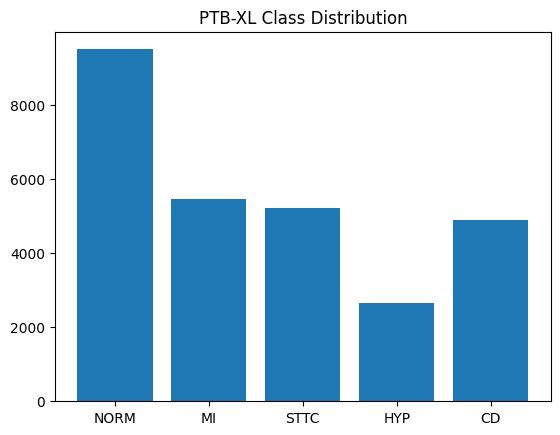

In [14]:
import matplotlib.pyplot as plt

label_counts = Counter(all_labels)

plt.bar(label_counts.keys(), label_counts.values())
plt.title("PTB-XL Class Distribution")
plt.show()

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

In [16]:
signals = np.load("/kaggle/working/ecg_signals.npy")
labels = np.load("/kaggle/working/ecg_labels.npy")

print(signals.shape)
print(labels.shape)

(21799, 12, 5000)
(21799, 5)


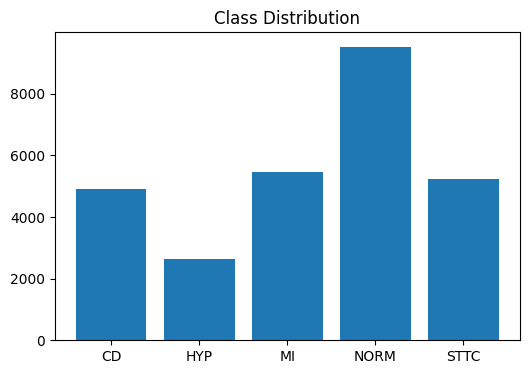

In [17]:
class_counts = labels.sum(axis=0)

plt.figure(figsize=(6,4))
plt.bar(range(len(class_counts)), class_counts)
plt.xticks(range(5), ["CD","HYP","MI","NORM","STTC"])
plt.title("Class Distribution")
plt.show()

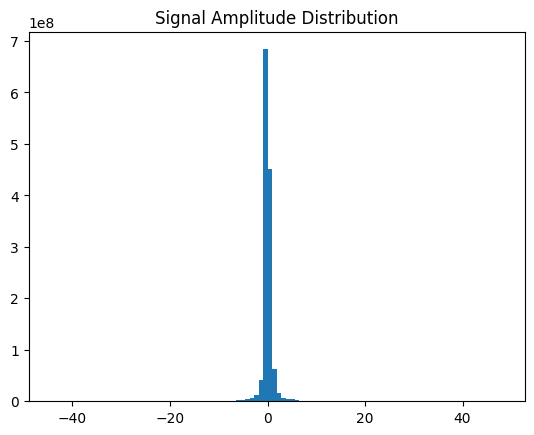

In [18]:
plt.hist(signals.flatten(), bins=100)
plt.title("Signal Amplitude Distribution")
plt.show()

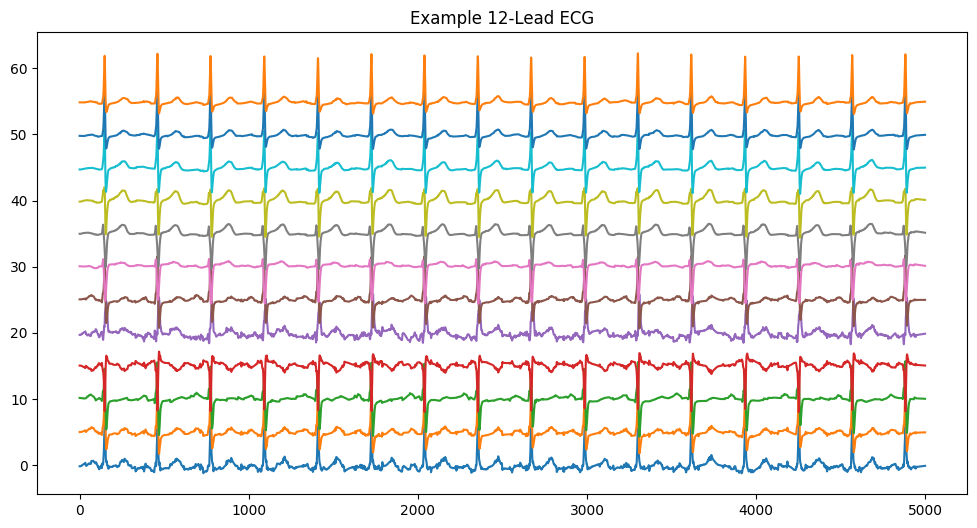

In [19]:
sample = signals[100]

plt.figure(figsize=(12,6))

for i in range(12):
    plt.plot(sample[i] + i*5)

plt.title("Example 12-Lead ECG")
plt.show()

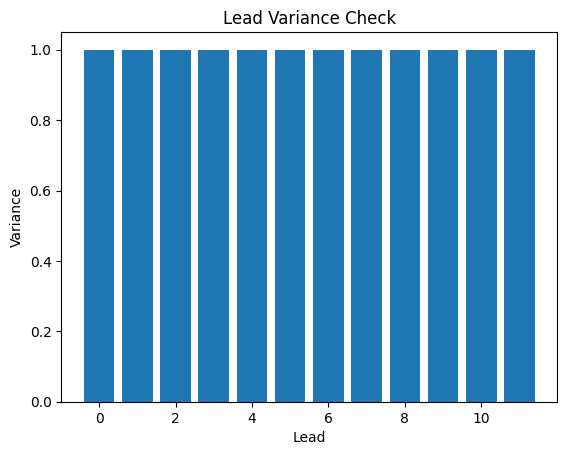

In [20]:
lead_variance = signals.var(axis=(0,2))

plt.bar(range(12), lead_variance)
plt.title("Lead Variance Check")
plt.xlabel("Lead")
plt.ylabel("Variance")
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

N = signals.shape[0]

variance_scores = []
peak_scores = []
snr_scores = []

for i in tqdm(range(N)):
    
    ecg = signals[i]   # (12,5000)

    # variance across leads
    variance = np.var(ecg)
    
    # peak amplitude
    peak = np.max(np.abs(ecg))
    
    # signal-to-noise ratio approximation
    signal_power = np.mean(ecg**2)
    noise_power = np.var(ecg - np.mean(ecg))
    
    snr = signal_power / (noise_power + 1e-8)
    
    variance_scores.append(variance)
    peak_scores.append(peak)
    snr_scores.append(snr)

100%|██████████| 21799/21799 [00:07<00:00, 2972.15it/s]


Compute Signal Quality Scores


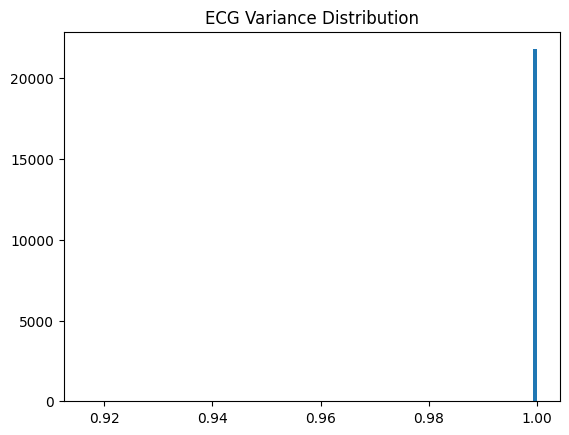

In [22]:
plt.hist(variance_scores, bins=100)
plt.title("ECG Variance Distribution")
plt.show()

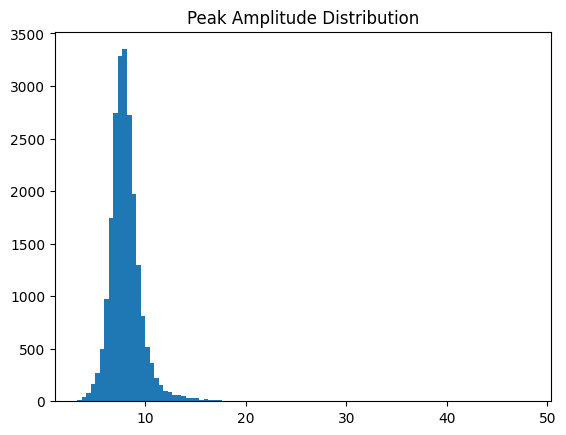

In [23]:
plt.hist(peak_scores, bins=100)
plt.title("Peak Amplitude Distribution")
plt.show()

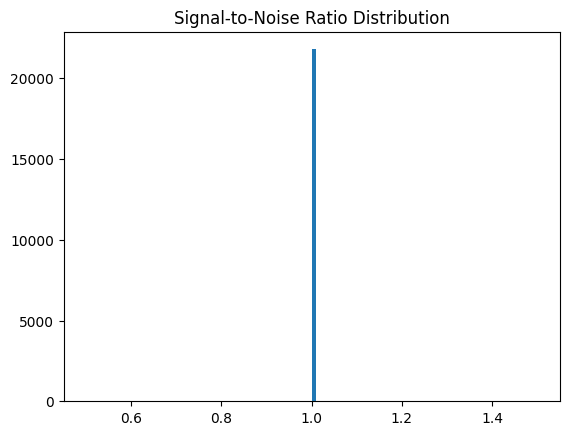

In [24]:
plt.hist(snr_scores, bins=100)
plt.title("Signal-to-Noise Ratio Distribution")
plt.show()

In [25]:
bad_samples = []

for i in range(N):

    if variance_scores[i] < 0.01:
        bad_samples.append(i)

    if peak_scores[i] > 20:
        bad_samples.append(i)

    if snr_scores[i] < 0.1:
        bad_samples.append(i)

bad_samples = list(set(bad_samples))

print("Bad signals detected:", len(bad_samples))

Bad signals detected: 35


In [26]:
good_indices = [i for i in range(N) if i not in bad_samples]

signals_clean = signals[good_indices]
labels_clean = labels[good_indices]

print("Original dataset:", signals.shape)
print("Clean dataset:", signals_clean.shape)

Original dataset: (21799, 12, 5000)
Clean dataset: (21764, 12, 5000)


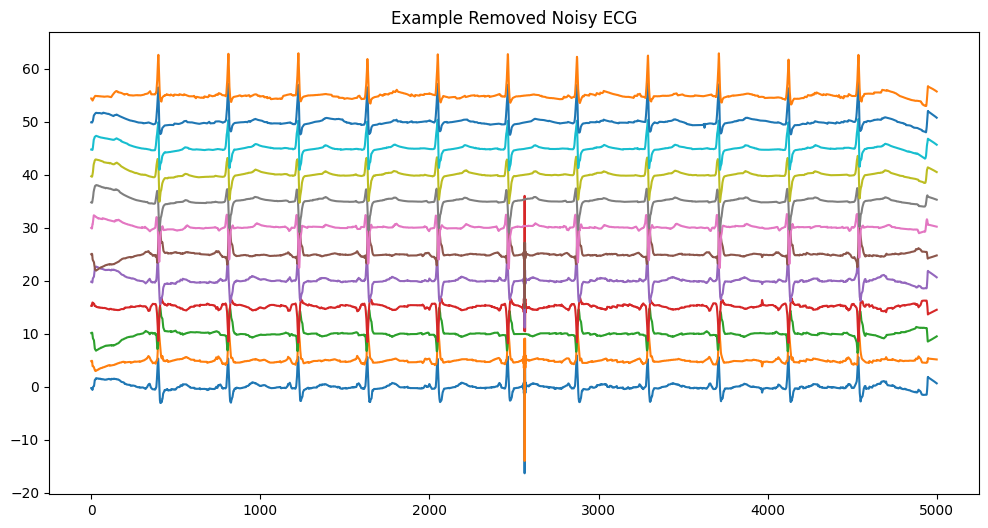

In [27]:
sample = signals[bad_samples[0]]

plt.figure(figsize=(12,6))

for i in range(12):
    plt.plot(sample[i] + i*5)

plt.title("Example Removed Noisy ECG")
plt.show()

In [28]:
import numpy as np

np.save("/kaggle/working/ecg_signals_clean.npy", signals_clean)
np.save("/kaggle/working/ecg_labels_clean.npy", labels_clean)

print("Clean dataset saved successfully")

Clean dataset saved successfully


In [29]:
import numpy as np
import torch

signals = np.load("/kaggle/working/ecg_signals_clean.npy")
labels  = np.load("/kaggle/working/ecg_labels_clean.npy")

print(signals.shape)
print(labels.shape)

(21764, 12, 5000)
(21764, 5)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    signals, labels, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

In [31]:
from torch.utils.data import Dataset

def add_noise(signal, noise_level=0.01):
    noise = np.random.normal(0, noise_level, signal.shape)
    return signal + noise

class ECGDataset(Dataset):

    def __init__(self, X, y, train=False):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float()
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        signal = self.X[idx]
        label = self.y[idx]

        if self.train:
            if np.random.rand() < 0.5:
                signal = torch.tensor(add_noise(signal.numpy())).float()

        return signal, label

In [32]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    ECGDataset(X_train, y_train, train=True),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    ECGDataset(X_val, y_val),
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    ECGDataset(X_test, y_test),
    batch_size=batch_size
)

In [33]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):

        super().__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels,
                               kernel_size=7, stride=stride, padding=3)

        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels,
                               kernel_size=7, padding=3)

        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):

        out = F.relu(self.bn1(self.conv1(x)))

        out = self.bn2(self.conv2(out))

        out += self.shortcut(x)

        out = F.relu(out)

        return out

In [34]:
class ECGResNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.layer1 = ResidualBlock(12, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 512, stride=2)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(512, 5)

    def forward(self, x):

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.pool(x).squeeze(-1)

        return self.fc(x)

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECGResNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

criterion = torch.nn.BCEWithLogitsLoss()

epochs = 20

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

/tmp/ipykernel_24/2900910099.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [36]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from tqdm import tqdm

for epoch in range(epochs):

    ############################
    # TRAIN
    ############################

    model.train()
    train_loss = 0

    for ecg, label in tqdm(train_loader):

        ecg = ecg.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        with autocast():

            output = model(ecg)
            loss = criterion(output, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    ############################
    # VALIDATION
    ############################

    model.eval()

    val_loss = 0
    preds = []
    targets = []

    with torch.no_grad():

        for ecg, label in val_loader:

            ecg = ecg.to(device)
            label = label.to(device)

            output = model(ecg)

            loss = criterion(output, label)

            val_loss += loss.item()

            preds.append(torch.sigmoid(output).cpu())
            targets.append(label.cpu())

    val_loss /= len(val_loader)

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    auc = roc_auc_score(targets, preds, average="macro")

    pred_binary = (preds > 0.5).astype(int)

    f1 = f1_score(targets, pred_binary, average="macro")
    precision = precision_score(targets, pred_binary, average="macro")
    recall = recall_score(targets, pred_binary, average="macro")

    ############################
    # PRINT METRICS
    ############################

    print(f"""
Epoch {epoch+1}

Train Loss: {train_loss:.4f}
Val Loss:   {val_loss:.4f}

AUROC:      {auc:.4f}
F1 Score:   {f1:.4f}
Precision:  {precision:.4f}
Recall:     {recall:.4f}
""")

  0%|          | 0/137 [00:00<?, ?it/s]/tmp/ipykernel_24/2065154287.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 137/137 [00:20<00:00,  6.57it/s]



Epoch 1

Train Loss: 0.3411
Val Loss:   0.3245

AUROC:      0.8988
F1 Score:   0.5893
Precision:  0.7570
Recall:     0.5429



  0%|          | 0/137 [00:00<?, ?it/s]/tmp/ipykernel_24/2065154287.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 137/137 [00:18<00:00,  7.53it/s]



Epoch 2

Train Loss: 0.3018
Val Loss:   0.3010

AUROC:      0.9088
F1 Score:   0.6815
Precision:  0.7628
Recall:     0.6245



  0%|          | 0/137 [00:00<?, ?it/s]/tmp/ipykernel_24/2065154287.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 137/137 [00:18<00:00,  7.40it/s]


...


Epoch 18

Train Loss: 0.2189
Val Loss:   0.2847

AUROC:      0.9208
F1 Score:   0.6917
Precision:  0.7658
Recall:     0.6554



  0%|          | 0/137 [00:00<?, ?it/s]/tmp/ipykernel_24/2065154287.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 137/137 [00:20<00:00,  6.71it/s]



Epoch 19

Train Loss: 0.2241
Val Loss:   0.3079

AUROC:      0.9232
F1 Score:   0.7230
Precision:  0.7339
Recall:     0.7298



  0%|          | 0/137 [00:00<?, ?it/s]/tmp/ipykernel_24/2065154287.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 137/137 [00:20<00:00,  6.70it/s]



Epoch 20

Train Loss: 0.2112
Val Loss:   0.2786

AUROC:      0.9270
F1 Score:   0.7269
Precision:  0.7710
Recall:     0.6957



In [37]:
torch.save(model.state_dict(),
           "/kaggle/working/ecg_encoder.pt")

In [38]:
encoder = torch.nn.Sequential(*list(model.children())[:-1])
encoder.eval()

Sequential(
  (0): ResidualBlock(
    (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(12, 64, kernel_size=(1,), stride=(2,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): ResidualBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(64, 128, kernel_size=(1,), stride=(2,))
      (1): 

In [39]:
sample = torch.tensor(signals_clean[:8]).float().to(device)

with torch.no_grad():
    feat = encoder(sample)

print(feat.shape)

torch.Size([8, 512, 1])


In [40]:
feat = feat.squeeze(-1)

In [41]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(torch.tensor(signals_clean).float(),
                        torch.tensor(labels_clean).float())

loader = DataLoader(dataset, batch_size=256)

encoder.eval()

embeddings = []
targets = []

with torch.no_grad():

    for ecg, label in loader:

        ecg = ecg.to(device)

        feat = encoder(ecg)

        feat = feat.squeeze(-1)

        embeddings.append(feat.cpu())
        targets.append(label)

embeddings = torch.cat(embeddings)
targets = torch.cat(targets)

print(embeddings.shape)

torch.Size([21764, 512])


In [42]:
import numpy as np

np.save("/kaggle/working/ecg_embeddings.npy", embeddings.numpy())
np.save("/kaggle/working/ecg_embedding_labels.npy", targets.numpy())

print("Embeddings saved")

Embeddings saved
